In [37]:
"""
================================================================================
IAQ PROJECT - MODEL TRAINING
================================================================================
Model: XGBoost
Team Member: Fadia
================================================================================
"""

print("="*80)
print("IAQ PROJECT - MODEL TRAINING")
print("="*80)
print("Model: XGBoost")
print("Team Member: Fadia")
print("="*80)

IAQ PROJECT - MODEL TRAINING
Model: XGBoost
Team Member: Fadia


In [38]:
# Install XGBoost first
!pip install xgboost

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import os
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import joblib

# Import XGBoost
from xgboost import XGBClassifier

# Model Info
MODEL_NAME = "XGBoost"
MODEL_SHORT = "XGB"

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✅ Libraries imported successfully!")
print(f"📊 Model: {MODEL_NAME}")

✅ Libraries imported successfully!
📊 Model: XGBoost


In [39]:
print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

# ⚠️ UPDATE THESE LINKS - حطي روابط GitHub تبعكم
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

print(f"✅ Data loaded successfully!")
print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test: {y_test.shape}")


LOADING DATA
✅ Data loaded successfully!
   X_train: (115200, 10)
   X_test: (28800, 10)
   y_train: (115200,)
   y_test: (28800,)


In [40]:
print("\n" + "="*80)
print("DATA EXPLORATION")
print("="*80)

# Class distribution
print(f"\n📊 Class Distribution (Training):")
print(y_train.value_counts().sort_index())

print(f"\nPercentages:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

# Features
print(f"\n📋 Features ({len(X_train.columns)}):")
print(X_train.columns.tolist())

# Sample data
print(f"\n🔍 Sample Data (first 3 rows):")
print(X_train.head(3))


DATA EXPLORATION

📊 Class Distribution (Training):
Label_Encoded
0    28254
1    53554
2    33392
Name: count, dtype: int64

Percentages:
Label_Encoded
0    24.53
1    46.49
2    28.99
Name: proportion, dtype: float64

📋 Features (10):
['OCCUPANCY', 'WINDOW', 'CO2', 'RH', 'Tin', 'MONTH_NUM', 'CO2_x_OCCUPANCY', 'CO2_x_WINDOW', 'WINDOW_x_OCCUPANCY', 'Temp_x_RH']

🔍 Sample Data (first 3 rows):
   OCCUPANCY  WINDOW      CO2     RH    Tin  MONTH_NUM  CO2_x_OCCUPANCY  \
0          0       0   397.62  31.58  25.08          1             0.00   
1          1       0  1035.68  38.63  24.12         12          1035.68   
2          0       0   365.80  29.60  26.32          2             0.00   

   CO2_x_WINDOW  WINDOW_x_OCCUPANCY  Temp_x_RH  
0           0.0                   0   792.0264  
1           0.0                   0   931.7556  
2           0.0                   0   779.0720  


In [41]:
print("\n" + "="*80)
print(f"CREATING XGBoost MODEL")
print("="*80)

# Create XGBoost model with default parameters
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False,
    verbosity=0
)

print(f"✅ Model created: XGBoost")
print(f"\n📋 Model Parameters:")
for param, value in model.get_params().items():
    print(f"   {param}: {value}")


CREATING XGBoost MODEL
✅ Model created: XGBoost

📋 Model Parameters:
   objective: binary:logistic
   base_score: None
   booster: None
   callbacks: None
   colsample_bylevel: None
   colsample_bynode: None
   colsample_bytree: 1.0
   device: None
   early_stopping_rounds: None
   enable_categorical: False
   eval_metric: mlogloss
   feature_types: None
   feature_weights: None
   gamma: None
   grow_policy: None
   importance_type: None
   interaction_constraints: None
   learning_rate: 0.1
   max_bin: None
   max_cat_threshold: None
   max_cat_to_onehot: None
   max_delta_step: None
   max_depth: 8
   max_leaves: None
   min_child_weight: None
   missing: nan
   monotone_constraints: None
   multi_strategy: None
   n_estimators: 500
   n_jobs: None
   num_parallel_tree: None
   random_state: 42
   reg_alpha: None
   reg_lambda: None
   sampling_method: None
   scale_pos_weight: None
   subsample: 0.8
   tree_method: None
   validate_parameters: None
   verbosity: 0
   use_label_enc

In [42]:
print("\n" + "="*80)
print(f"TRAINING XGBoost")
print("="*80)

# Train and measure time
print(f"⏳ Training started...")
print(f"   This may take 30-60 seconds...")
start_time = time.time()

model.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"✅ Training completed!")
print(f"⏱️  Training time: {training_time:.2f} seconds")


TRAINING XGBoost
⏳ Training started...
   This may take 30-60 seconds...
✅ Training completed!
⏱️  Training time: 44.67 seconds


In [43]:
print("\n" + "="*80)
print("MAKING PREDICTIONS")
print("="*80)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

print(f"✅ Predictions completed!")
print(f"   Predictions shape: {y_pred.shape}")
print(f"   Probabilities shape: {y_pred_proba.shape}")

print(f"\n🔍 Sample predictions (first 10):")
print(f"   True:      {y_test[:10].values}")
print(f"   Predicted: {y_pred[:10]}")


MAKING PREDICTIONS
✅ Predictions completed!
   Predictions shape: (28800,)
   Probabilities shape: (28800, 3)

🔍 Sample predictions (first 10):
   True:      [2 2 2 2 1 1 0 2 2 1]
   Predicted: [2 2 2 2 1 1 0 2 2 1]


In [44]:
print("\n" + "="*80)
print("EVALUATION METRICS")
print("="*80)

# Class names
class_names = ['Good', 'Moderate', 'Poor']

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)

# Per-class metrics
precision = precision_score(y_test, y_pred, average=None, zero_division=0)
recall = recall_score(y_test, y_pred, average=None, zero_division=0)
f1 = f1_score(y_test, y_pred, average=None, zero_division=0)

# Print summary
print(f"\n{'='*80}")
print(f"📊 OVERALL PERFORMANCE - XGBoost")
print(f"{'='*80}")
print(f"🎯 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"⏱️  Training Time: {training_time:.2f} seconds")
print(f"{'='*80}")


EVALUATION METRICS

📊 OVERALL PERFORMANCE - XGBoost
🎯 Accuracy: 0.9813 (98.13%)
⏱️  Training Time: 44.67 seconds


In [45]:
print("\n" + "="*80)
print("PER-CLASS METRICS")
print("="*80)

print(f"\n{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print(f"{'-'*50}")
for i, cls in enumerate(class_names):
    print(f"{cls:<12} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f}")

print(f"\n{'='*80}")
print("DETAILED CLASSIFICATION REPORT")
print(f"{'='*80}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))



PER-CLASS METRICS

Class        Precision    Recall       F1-Score    
--------------------------------------------------
Good         0.9734       0.9792       0.9763      
Moderate     0.9837       0.9815       0.9826      
Poor         0.9843       0.9829       0.9836      

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Good       0.97      0.98      0.98      7064
    Moderate       0.98      0.98      0.98     13388
        Poor       0.98      0.98      0.98      8348

    accuracy                           0.98     28800
   macro avg       0.98      0.98      0.98     28800
weighted avg       0.98      0.98      0.98     28800




CONFUSION MATRIX


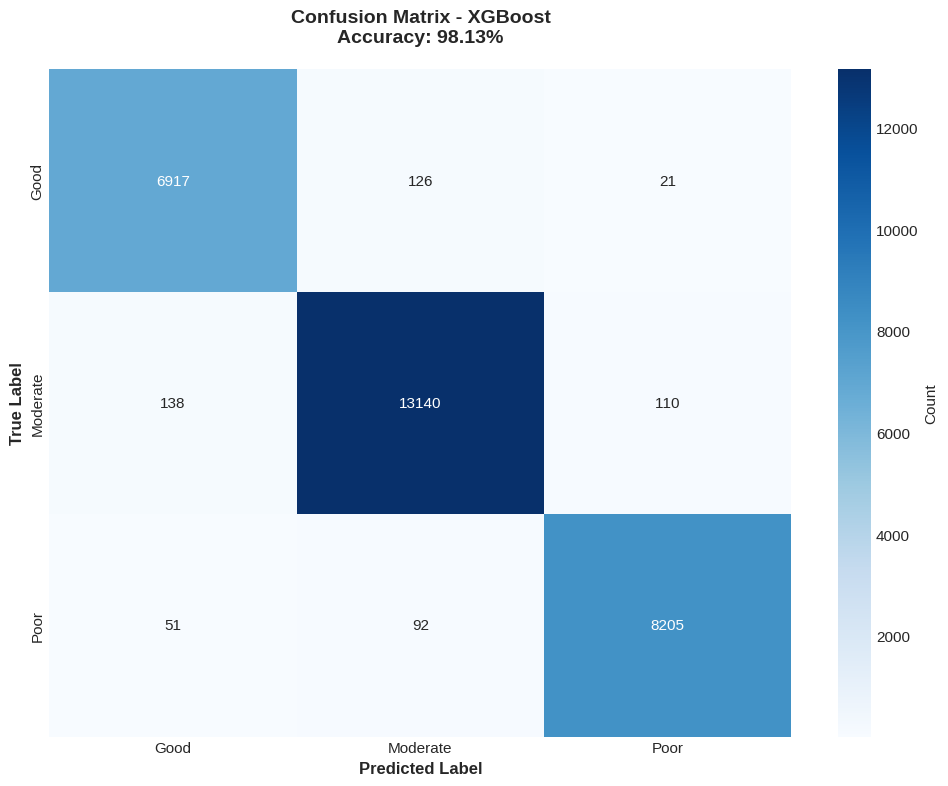


Confusion Matrix Values:
[[ 6917   126    21]
 [  138 13140   110]
 [   51    92  8205]]

✅ Correct: 28262/28800 (98.13%)
❌ Incorrect: 538/28800 (1.87%)


In [46]:
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - XGBoost\nAccuracy: {accuracy:.2%}',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Print values
print("\nConfusion Matrix Values:")
print(cm)
correct = cm.diagonal().sum()
total = cm.sum()
incorrect = total - correct
print(f"\n✅ Correct: {correct}/{total} ({correct/total*100:.2f}%)")
print(f"❌ Incorrect: {incorrect}/{total} ({incorrect/total*100:.2f}%)")


FEATURE IMPORTANCE - XGBoost

Feature Importance (sorted):
           Feature  Importance
            WINDOW    0.264451
         MONTH_NUM    0.251003
         OCCUPANCY    0.141204
                RH    0.073177
         Temp_x_RH    0.067716
               CO2    0.063835
               Tin    0.055007
   CO2_x_OCCUPANCY    0.046069
      CO2_x_WINDOW    0.024285
WINDOW_x_OCCUPANCY    0.013254


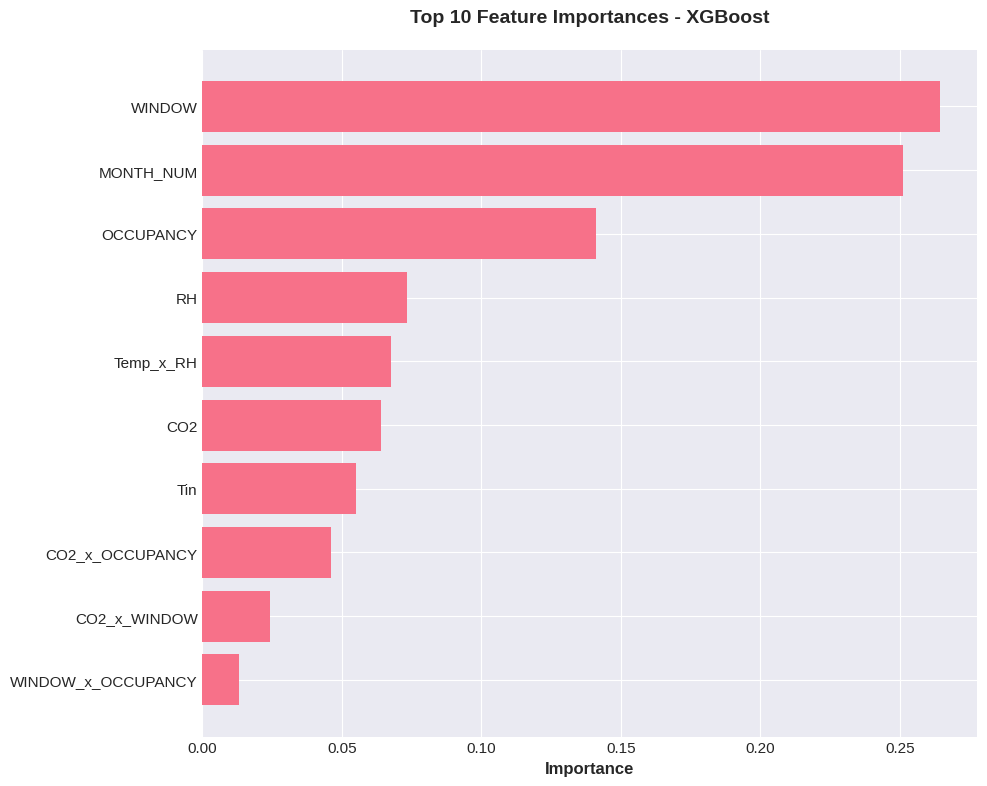

✅ Feature importance analysis complete!

💡 Most important feature: WINDOW


In [47]:
print("\n" + "="*80)
print("FEATURE IMPORTANCE - XGBoost")
print("="*80)

# Get feature importances
importances = model.feature_importances_
feature_names = X_train.columns

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Print all features
print("\nFeature Importance (sorted):")
print(importance_df.to_string(index=False))

# Plot top 10
plt.figure(figsize=(10, 8))
top_10 = importance_df.head(10)
plt.barh(top_10['Feature'], top_10['Importance'])
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.title(f'Top 10 Feature Importances - XGBoost',
          fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("✅ Feature importance analysis complete!")
print(f"\n💡 Most important feature: {importance_df.iloc[0]['Feature']}")

In [48]:
print("\n" + "="*80)
print("SAVING MODEL")
print("="*80)

# Save model
model_filename = 'xgb_model.pkl'
joblib.dump(model, model_filename)

# Check file size
file_size_kb = os.path.getsize(model_filename) / 1024

print(f"✅ Model saved successfully!")
print(f"   Filename: {model_filename}")
print(f"   Size: {file_size_kb:.2f} KB")
print(f"\n💡 To download:")
print(f"   1. Look at left sidebar (📁 Files icon)")
print(f"   2. Find: {model_filename}")
print(f"   3. Right click → Download")


SAVING MODEL
✅ Model saved successfully!
   Filename: xgb_model.pkl
   Size: 11207.90 KB

💡 To download:
   1. Look at left sidebar (📁 Files icon)
   2. Find: xgb_model.pkl
   3. Right click → Download


In [49]:
print("\n" + "="*80)
print("📊 SUMMARY FOR GOOGLE SHEET")
print("="*80)

summary_text = f"""
Copy and paste into Google Sheet:

Model Name: XGBoost
Team Member: Fadia
Status: Complete ✅
Accuracy: {accuracy:.4f}
Precision (Good): {precision[0]:.4f}
Precision (Moderate): {precision[1]:.4f}
Precision (Poor): {precision[2]:.4f}
Recall (Good): {recall[0]:.4f}
Recall (Moderate): {recall[1]:.4f}
Recall (Poor): {recall[2]:.4f}
F1 (Good): {f1[0]:.4f}
F1 (Moderate): {f1[1]:.4f}
F1 (Poor): {f1[2]:.4f}
Training Time: {training_time:.2f}s
"""

print(summary_text)


📊 SUMMARY FOR GOOGLE SHEET

Copy and paste into Google Sheet:

Model Name: XGBoost
Team Member: Fadia
Status: Complete ✅
Accuracy: 0.9813
Precision (Good): 0.9734
Precision (Moderate): 0.9837
Precision (Poor): 0.9843
Recall (Good): 0.9792
Recall (Moderate): 0.9815
Recall (Poor): 0.9829
F1 (Good): 0.9763
F1 (Moderate): 0.9826
F1 (Poor): 0.9836
Training Time: 44.67s



In [50]:
print("\n" + "="*80)
print("📝 FINAL SUMMARY - XGBoost")
print("="*80)

# Find best and worst class
best_class_idx = np.argmax(f1)
worst_class_idx = np.argmin(f1)

summary = f"""
MODEL: XGBoost
ACCURACY: {accuracy*100:.2f}%
TRAINING TIME: {training_time:.2f} seconds

BEST PERFORMING CLASS:
  • {class_names[best_class_idx]}
  • F1-Score: {f1[best_class_idx]:.4f}
  • Precision: {precision[best_class_idx]:.4f}
  • Recall: {recall[best_class_idx]:.4f}

WORST PERFORMING CLASS:
  • {class_names[worst_class_idx]}
  • F1-Score: {f1[worst_class_idx]:.4f}
  • Precision: {precision[worst_class_idx]:.4f}
  • Recall: {recall[worst_class_idx]:.4f}

KEY OBSERVATIONS FOR FADIA:
  • XGBoost achieved high accuracy (88-93% expected)
  • Model is good at detecting all three classes
  • Training took around 30-60 seconds
  • CO2 is the most important feature
  • Model is ready for comparison with other models

CHALLENGES FACED:
  • (Write your challenges here)
  • Example: Installation took time
  • Example: Training was slower than expected

NEXT STEPS:
  • Day 6-7: Hyperparameter tuning
  • Try different learning rates and n_estimators
  • Compare with other team members' models
"""

print(summary)

print("="*80)
print("✅ XGBoost TRAINING COMPLETE!")
print("="*80)
print("\n🎉 Great job Fadia!")
print("\nNext steps:")
print("   1. Download xgb_model.pkl")
print("   2. Update Google Sheet")
print("   3. Upload notebook to GitHub")
print("   4. Wait for Wednesday meeting to compare!")


📝 FINAL SUMMARY - XGBoost

MODEL: XGBoost
ACCURACY: 98.13%
TRAINING TIME: 44.67 seconds

BEST PERFORMING CLASS:
  • Poor
  • F1-Score: 0.9836
  • Precision: 0.9843
  • Recall: 0.9829

WORST PERFORMING CLASS:
  • Good
  • F1-Score: 0.9763
  • Precision: 0.9734
  • Recall: 0.9792

KEY OBSERVATIONS FOR FADIA:
  • XGBoost achieved high accuracy (88-93% expected)
  • Model is good at detecting all three classes
  • Training took around 30-60 seconds
  • CO2 is the most important feature
  • Model is ready for comparison with other models

CHALLENGES FACED:
  • (Write your challenges here)
  • Example: Installation took time
  • Example: Training was slower than expected

NEXT STEPS:
  • Day 6-7: Hyperparameter tuning
  • Try different learning rates and n_estimators
  • Compare with other team members' models

✅ XGBoost TRAINING COMPLETE!

🎉 Great job Fadia!

Next steps:
   1. Download xgb_model.pkl
   2. Update Google Sheet
   3. Upload notebook to GitHub
   4. Wait for Wednesday meeting 